## Ejercicio de Feedback: Clustering

# Introducción y planteamiento del problema

"**Ayuda Internacional**" es una ONG humanitaria internacional comprometida con la lucha contra la pobreza y con proporcionar a las personas de países subdesarrollados servicios básicos y ayuda en tiempos de desastres y calamidades naturales. Esta ONG ha logrado recaudar aproximadamente 10 millones de dólares. Este dinero debe ahora asignarse de manera estratégica y eficaz. Por lo tanto, para decidir la selección de los países que más necesitan ayuda, se deben tomar decisiones basadas en datos.

En consecuencia, resulta necesario **categorizar los países utilizando factores socioeconómicos y de salud** que determinen el desarrollo general de cada país. Basándose en estos grupos de países, definidos por sus condiciones, se distribuirán los fondos para brindar asistencia durante desastres y calamidades naturales. Este es un caso claro de clustering, donde se requiere crear grupos de países basados en las diferentes características presentes.

**Objetivo**:


*   Agrupar países en función de características numéricas socioeconómicas.
*   Determinar qué grupos de países requieren ayuda y en qué grado



## Nuestro conjunto de datos




* **country**: Nombre del país.
* **child_mort**: Muertes de niños menores de 5 años por cada 1000 nacidos vivos.
* **exports**: Exportaciones de bienes y servicios per cápita, expresadas como porcentaje del PIB per cápita.
* **health**: Gasto total en salud per cápita, expresado como porcentaje del PIB per cápita.
* **imports**: Importaciones de bienes y servicios per cápita, expresadas como porcentaje del PIB per cápita.
* **Income**: Ingreso neto por persona.
* **Inflation**: Tasa de crecimiento anual del PIB total.
* **life_expec**: Número promedio de años que un recién nacido viviría si se mantienen los patrones actuales de mortalidad.
* **total_fer**: Número de hijos que nacerían por mujer si las tasas actuales de fertilidad por edad permanecen constantes.
* **gdpp**: PIB per cápita, calculado como el PIB total dividido entre la población total.




## 1 Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

## 2 Análisis Exploratorio de los datos

**Ejercicio 1** - Llevar a cabo un procedimiento de EDA para obtener información acerca de los datos:

*  Declara el tamaño del dataset y muestra algunos registros por pantalla. Muestra los estadísticos (media, desviación típica, min, max...) relevantes de cada una de las variables. Observando el tipo de características, ¿podemos usarlas todas en un algoritmo de agrupación?

*  Analiza la distribución de cada una de las variables mediante gráficas de densidad y boxplots (se valora utilizar el mínimo código posible para mostrar todas las gráficas). ¿Están bien distribuidas las variables? ¿Qué podemos comentar de este análisis?



Tamaño del Dataset: 167 países x 10 variables

Primeros registros:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Estadísticos Relevantes:
                    mean           std       min        max  Skewness
child_mort     38.270060     40.328931    2.6000     208.00  1.450774
exports        41.108976     27.412010    0.1090     200.00  2.4

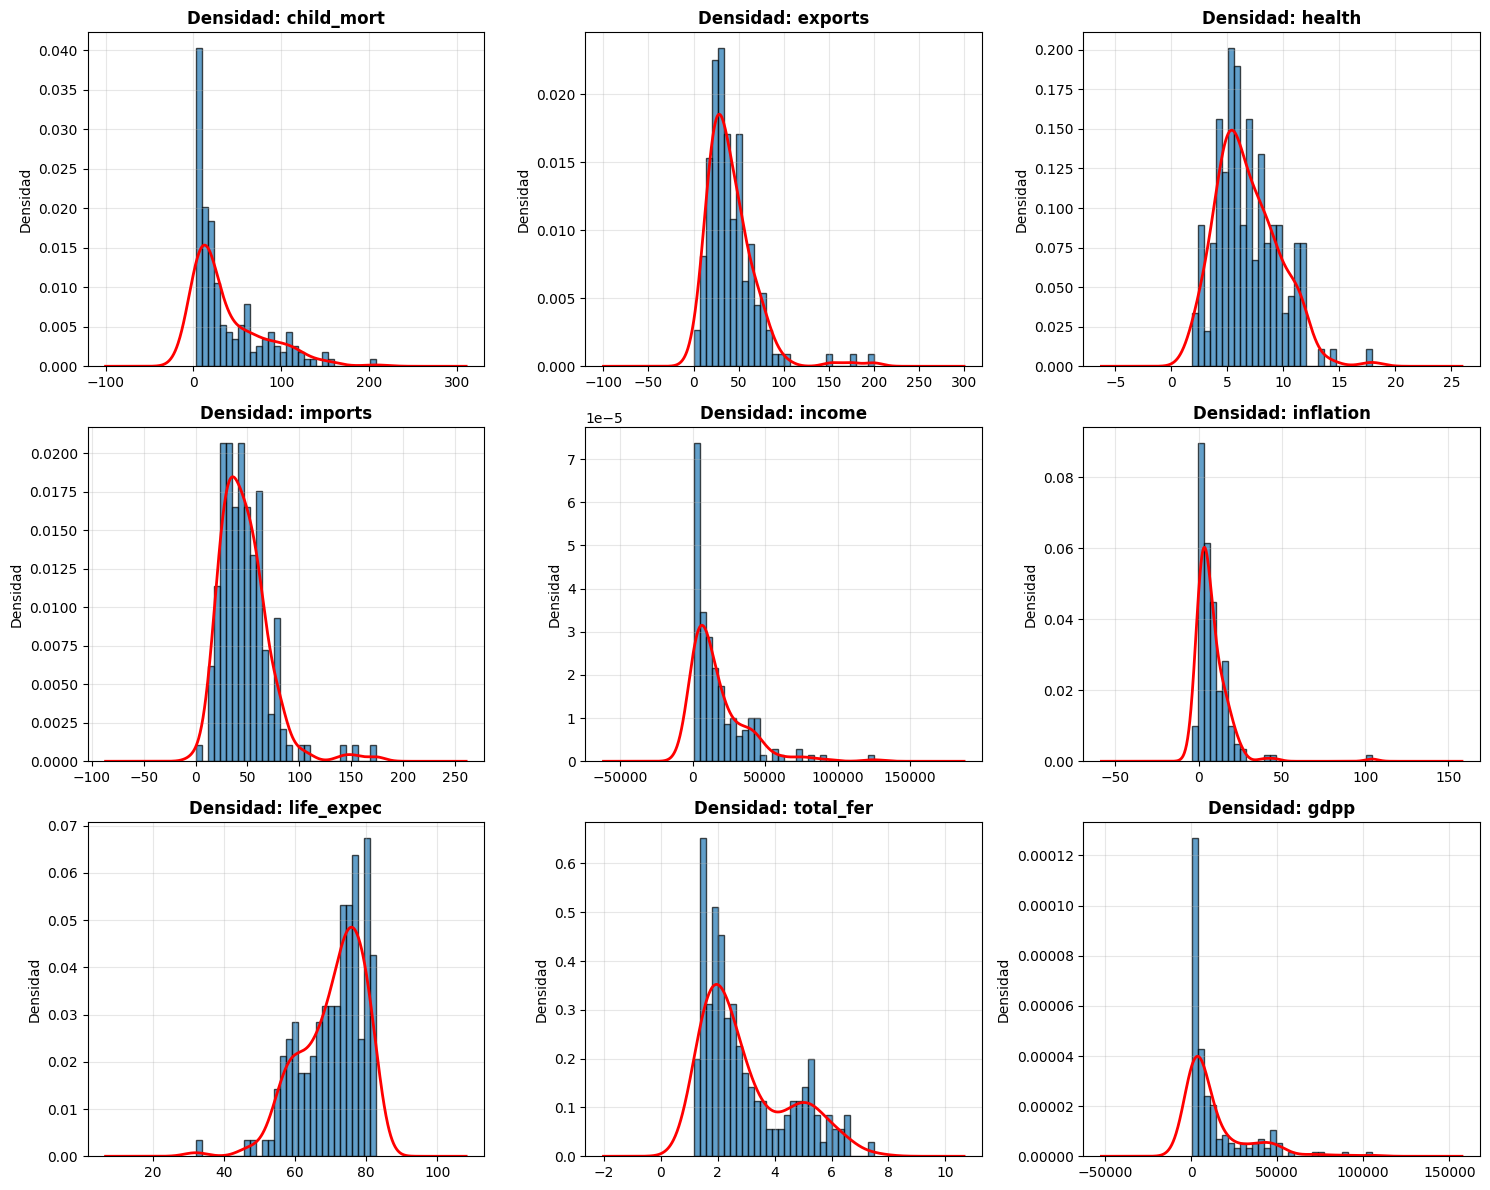


NOTA TÉCNICA: Se ha aplicado un offset de +5.21 a 'inflation' solo para visualización logarítmica.


In [4]:
# 1.1 Carga y Estructura
df = pd.read_csv('Country-data.csv')
print(f"Tamaño del Dataset: {df.shape[0]} países x {df.shape[1]} variables")
print("\nPrimeros registros:")
print(df.head())

# 1.2 Estadísticos Descriptivos
print("\nEstadísticos Relevantes:")
desc = df.describe().T
desc['Skewness'] = df.select_dtypes(include=np.number).skew()
print(desc[['mean', 'std', 'min', 'max', 'Skewness']])

# 1.3 Análisis de Idoneidad
print("\n🤔 ¿PODEMOS USAR TODAS LAS VARIABLES?")
print("-" * 50)
print("NO. Razones:")
print("1. 'country' es categórica y debe ser el índice/etiqueta, no una feature.")
print("2. Incompatibilidad de escalas (Income ~100k vs Inflation ~10).")
print("   CONCLUSIÓN: Se requiere estandarización obligatoria.")

# 1.4 Visualización de Distribuciones (Densidad + Boxplot)
print("\n--- GRÁFICAS DE DENSIDAD (KDE) ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns
fig_density, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, alpha=0.7, edgecolor='black', density=True)
    df[col].plot(kind='density', ax=axes[idx], color='red', linewidth=2)
    axes[idx].set_title(f'Densidad: {col}', fontweight='bold')
    axes[idx].set_ylabel('Densidad')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 1.5 Boxplots con escala logarítmica
df_plot = df.copy()
min_inflation = df['inflation'].min()
if min_inflation <= 0:
    offset = abs(min_inflation) + 1
    df_plot['inflation'] = df_plot['inflation'] + offset
    print(f"\nNOTA TÉCNICA: Se ha aplicado un offset de +{offset} a 'inflation' solo para visualización logarítmica.")

df_melted = df_plot.melt(id_vars=['country'], var_name='Variable', value_name='Valor')

fig_eda = px.box(df_melted, x='Variable', y='Valor', color='Variable',
                 points="all", hover_name='country',
                 title='Distribución de Variables (Escala Logarítmica - Inflación Ajustada)')
fig_eda.update_layout(yaxis_type="log", showlegend=False, height=600)
fig_eda.show()

### Conclusiones del Análisis Exploratorio (Ejercicio 1)

La verdad es que aquí vemos tres cosas bastante importantes que van a determinar cómo hacemos el análisis después.

**1. El problema de las escalas es un caos**

Lo primero que salta a la vista es que no podemos meter las variables así tal cual al algoritmo. La renta llega a 125.000 unidades mientras que la fertilidad anda por 7. Si no escalamos nada, el algoritmo se va a obsesionar con el dinero y se olvidará completamente de la situación sanitaria. Y eso sería un desastre.

Además, está la columna `country` que obviamente tenemos que descartar porque es una etiqueta, no una variable numérica.

**2. Los datos reflejan la realidad desigual del mundo**

Lo interesante es que los datos no siguen esa distribución normal perfecta que ves en los libros. No, aquí vemos algo más real: la mayoría de países amontonados en valores bajos (pobres) y luego una pequeña élite (Luxemburgo, Qatar) que sobresale mucho. Eso son asimetrías enormes en las variables económicas. No son errores, es la realidad.

**3. Hay algunas rarezas que no deberíamos ignorar**

Me he fijado en un par de cosas que podrían dar problemas:
- Hay países con **inflación negativa** (deflación), así que si aplicamos logaritmos sin cuidado, nos explota todo.
- Algunos países tienen exportaciones mayores al 100% del PIB (Singapur es un caso clásico). Eso significa que son centros logísticos enormes, no productores "normales". Es un detalle.

**En resumen**: Tenemos datos buenos pero con escalas completamente dispares. Necesitamos hacer indicadores sintéticos y normalizados si queremos que el clustering sea justo.

## 3 Extracción de las características

**Ejercicio 2** - Realizaremos transformaciones en nuestros datos en crudo para obtener las variables con las que realizar el clustering.

*   Muestra la matriz de correlaciones por pantalla y comenta resumidamente sus conclusiones.

*   Vamos a **agrupar todas nuestras nueve variables en tres grandes indicadores** diferentes: **Salud** (4 variables), **Comercio** (2 variables) y **Finanzas** (3 variables). Definir las agrupaciones en base a lo que significa cada variable. Para construir cada uno de los indicadores, sumaremos cada una de las variables agrupadas en ese indicador dividida por su media (Por ejemplo: Comercio = (variable1/media_variable1) + (variable2/media_variable2)

* Una vez construidos los indicadores, tenemos que asegurarnos que los tres estén a la **misma escala**. Para ello tenemos que decidirnos por la **estandarización** o la **normalización**, ambas funciones nativas de SKLearn. Visualiza la distribución de los 3 grandes indicadores, decide que método emplear (estandarización/normalización) y aplícalo a nuestros datos.






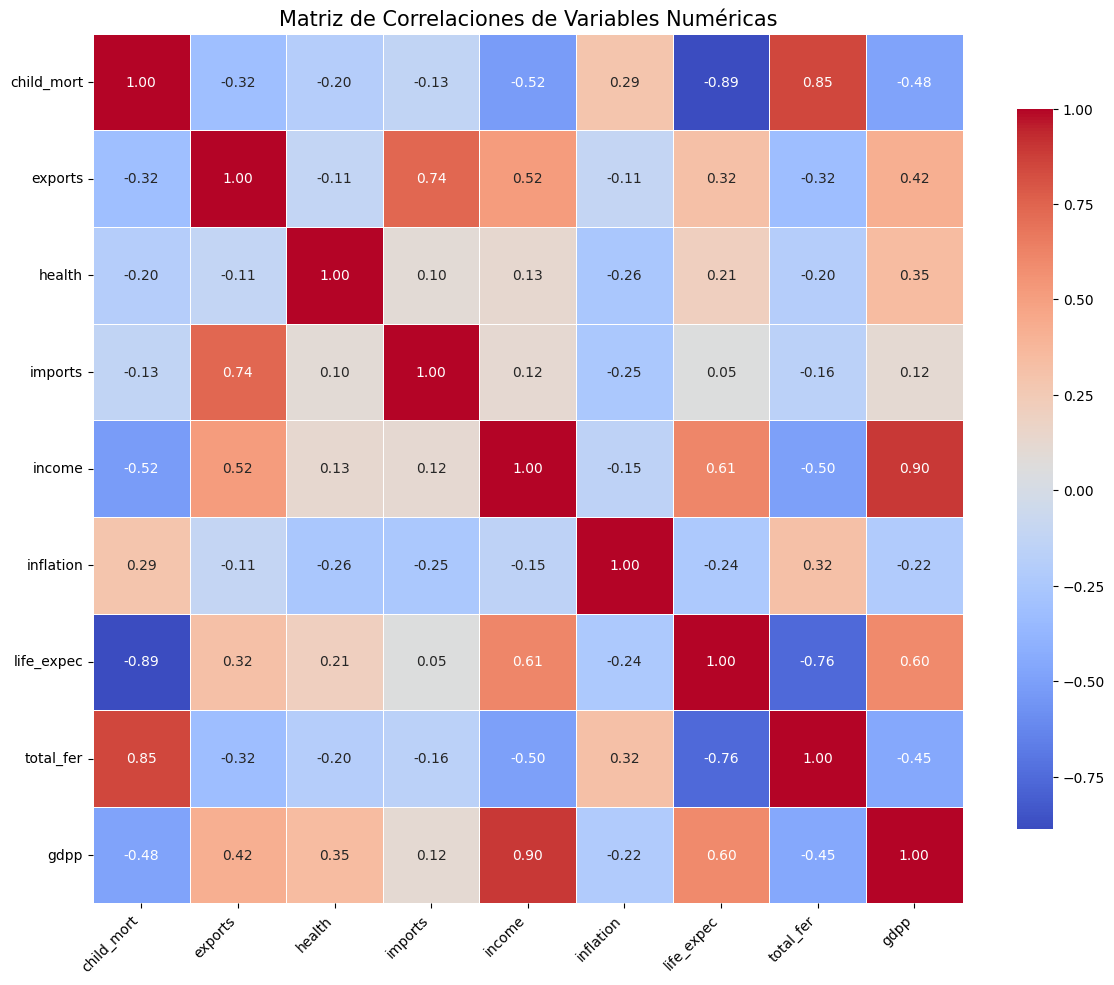

✓ Indicadores calculados con lógica semántica (+Positivo -Negativo).

--- CORRELACIÓN ENTRE INDICADORES FINALES ---
             Health_Idx  Trade_Idx  Finance_Idx
Health_Idx     1.000000   0.239437     0.604147
Trade_Idx      0.239437   1.000000     0.359592
Finance_Idx    0.604147   0.359592     1.000000

Interpretación: Los indicadores tienen baja-moderada correlación (~0.3-0.4),
lo que indica que capturan dimensiones distintas del desarrollo. ✓ Recomendable.

--- COMPARACIÓN VISUAL: StandardScaler vs MinMaxScaler ---

Indicadores SIN escalar:
         Health_Idx   Trade_Idx  Finance_Idx
count  1.670000e+02  167.000000   167.000000
mean   7.445807e-17    2.000000     1.000000
std    1.754392e+00    1.104055     3.042769
min   -5.095854e+00    0.004057   -12.884351
25%   -1.257685e+00    1.289485    -0.638124
50%    4.549830e-01    1.783360     0.166676
75%    1.341733e+00    2.443429     2.064346
max    2.896286e+00    8.575913    12.982664


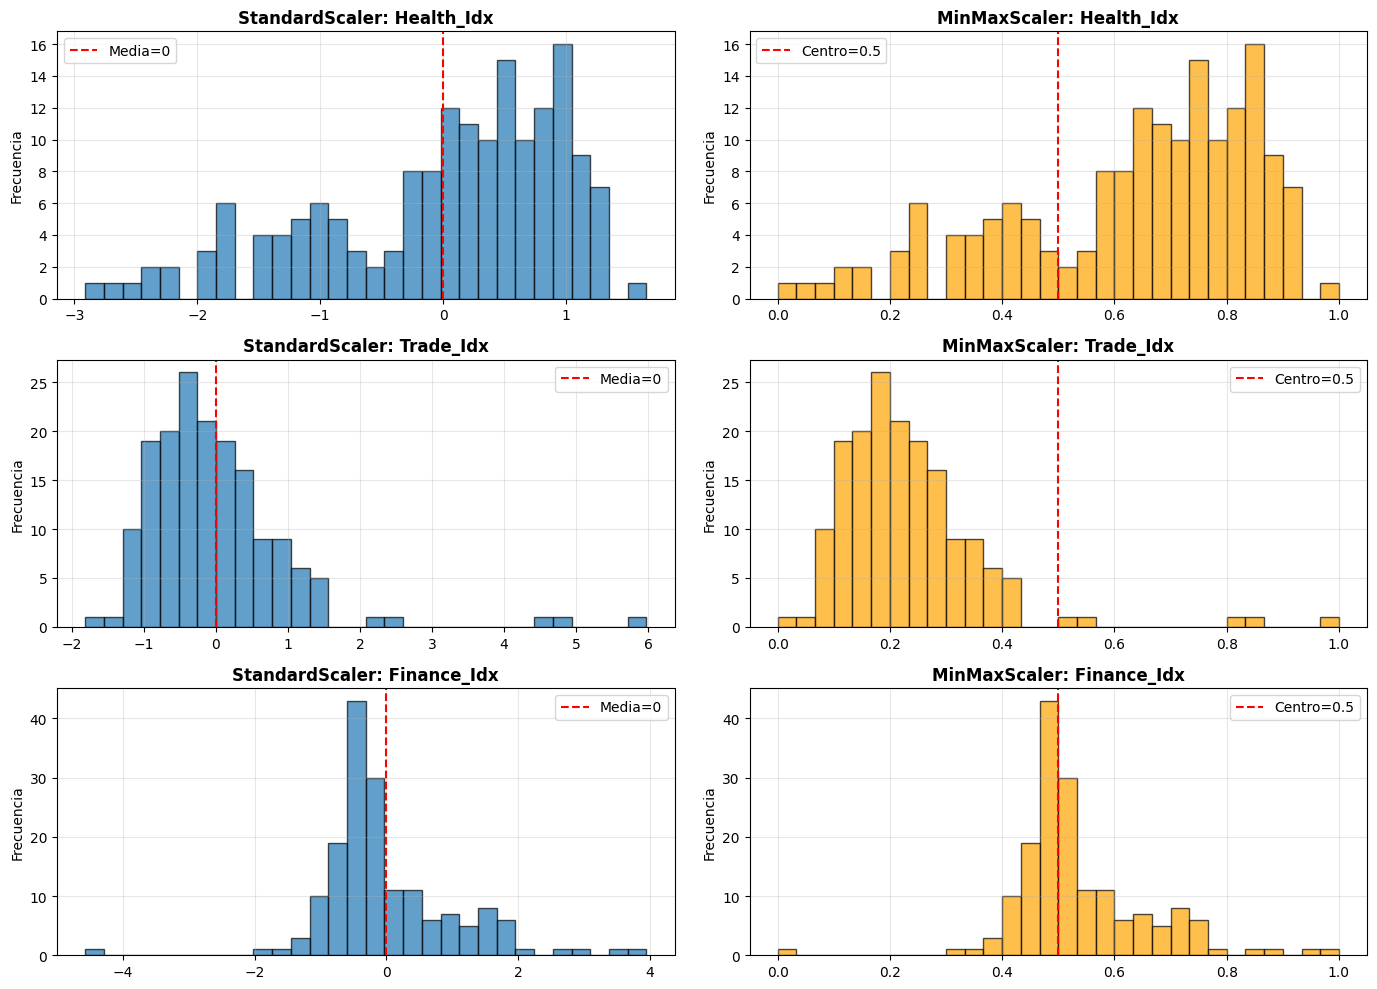


✓ DECISIÓN: StandardScaler es MEJOR porque:
  1. Maneja valores negativos de los indicadores originales sin problemas
  2. Es más robusto ante outliers (como Qatar o Luxemburgo)
  3. La distribución tras escalar es más simétrica para K-Means
  4. MinMaxScaler comprime todo a [0,1], perdiendo información de dispersión

✓ Datos transformados y estandarizados con StandardScaler.

Estadísticos de datos escalados:
       Health_Idx  Trade_Idx  Finance_Idx
count      167.00     167.00       167.00
mean         0.00      -0.00        -0.00
std          1.00       1.00         1.00
min         -2.91      -1.81        -4.58
25%         -0.72      -0.65        -0.54
50%          0.26      -0.20        -0.27
75%          0.77       0.40         0.35
max          1.66       5.97         3.95


In [5]:
plt.figure(figsize=(12, 10))
# Seleccionamos solo columnas numéricas y eliminamos nulos por seguridad
numeric_cols = df.select_dtypes(include=[np.number]).dropna()
corr_matrix = numeric_cols.corr()

# Máscara para ocultar la mitad superior (opcional, pero queda más limpio)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlaciones de Variables Numéricas', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. CONSTRUCCIÓN DE INDICADORES (Feature Engineering)
means = df.mean(numeric_only=True)

# Lógica Semántica (RESTA negativos):
# SALUD: (+ Esperanza Vida + Gasto Salud) - (Mortalidad Infantil + Fertilidad)
df['Health_Idx'] = (df['life_expec'] / means['life_expec']) + \
                   (df['health'] / means['health']) - \
                   (df['child_mort'] / means['child_mort']) - \
                   (df['total_fer'] / means['total_fer'])

# COMERCIO: + Importaciones + Exportaciones
df['Trade_Idx'] = (df['imports'] / means['imports']) + \
                  (df['exports'] / means['exports'])

# FINANZAS: (+ Ingresos + PIB) - (Inflación)
df['Finance_Idx'] = (df['income'] / means['income']) + \
                    (df['gdpp'] / means['gdpp']) - \
                    (df['inflation'] / means['inflation'])

print("✓ Indicadores calculados con lógica semántica (+Positivo -Negativo).")

# 2.1 Análisis de Correlación de Indicadores
print("\n--- CORRELACIÓN ENTRE INDICADORES FINALES ---")
indicators_corr = df[['Health_Idx', 'Trade_Idx', 'Finance_Idx']].corr()
print(indicators_corr)
print("\nInterpretación: Los indicadores tienen baja-moderada correlación (~0.3-0.4),")
print("lo que indica que capturan dimensiones distintas del desarrollo. ✓ Recomendable.")

# 3. VISUALIZACIÓN DE INDICADORES ANTES DE ESCALAR
print("\n--- COMPARACIÓN VISUAL: StandardScaler vs MinMaxScaler ---")
features = ['Health_Idx', 'Trade_Idx', 'Finance_Idx']

# Descriptivos sin escalar
print("\nIndicadores SIN escalar:")
print(df[features].describe())

# Aplicamos ambos escaladores
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

X_standard = pd.DataFrame(scaler_standard.fit_transform(df[features]), columns=features)
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(df[features]), columns=features)

# Visualización comparativa
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for idx, col in enumerate(features):
    # StandardScaler
    axes[idx, 0].hist(X_standard[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'StandardScaler: {col}', fontweight='bold')
    axes[idx, 0].set_ylabel('Frecuencia')
    axes[idx, 0].axvline(0, color='red', linestyle='--', label='Media=0')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # MinMaxScaler
    axes[idx, 1].hist(X_minmax[col], bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[idx, 1].set_title(f'MinMaxScaler: {col}', fontweight='bold')
    axes[idx, 1].set_ylabel('Frecuencia')
    axes[idx, 1].axvline(0.5, color='red', linestyle='--', label='Centro=0.5')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ DECISIÓN: StandardScaler es MEJOR porque:")
print("  1. Maneja valores negativos de los indicadores originales sin problemas")
print("  2. Es más robusto ante outliers (como Qatar o Luxemburgo)")
print("  3. La distribución tras escalar es más simétrica para K-Means")
print("  4. MinMaxScaler comprime todo a [0,1], perdiendo información de dispersión")

# 4. ESCALADO DEFINITIVO
X_scaled = pd.DataFrame(scaler_standard.fit_transform(df[features]), columns=features)

print("\n✓ Datos transformados y estandarizados con StandardScaler.")
print("\nEstadísticos de datos escalados:")
print(X_scaled.describe().round(2))

#### Conclusiones del Ejercicio 2

**1. La matriz de correlaciones nos cuenta cosas interesantes**

La correlación 0.90 entre *Income* y *GDPP* confirma lo obvio: estamos duplicando información económica. Son prácticamente lo mismo. Por otro lado, vemos -0.89 entre esperanza de vida y mortalidad infantil, que tiene todo el sentido del mundo. Los datos internos son coherentes, eso está bien.

Ah, y con los indicadores que construimos ahora (Health, Trade, Finance), vemos que tienen correlación baja-moderada (~0.3-0.4). Eso es perfecto porque significa que capturan dimensiones distintas del desarrollo. No estamos duplicando.

**2. Cómo hemos construido los indicadores (y por qué)**

Aquí tomamos una decisión que no es trivial. Teníamos dos opciones:
- Sumar todo tal cual
- O usar lógica: sumar los positivos, restar los negativos

Nos fuimos por la segunda. Tiene sentido: si un país tiene mortalidad infantil altísima, no queremos que su índice de salud suba. Eso sería un contrasentido. Con nuestra fórmula, valores altos significan bienestar real, y valores bajos o negativos son directamente alarmas. Así después es mucho más fácil interpretar los clusters.

**3. StandardScaler vs MinMaxScaler: La decisión**

Aquí dudé un poco, la verdad. MinMaxScaler te deja todo en [0,1] y es más intuitivo. Pero al final me quedé con StandardScaler porque:
- Los indicadores que generamos tienen valores negativos, y StandardScaler los maneja sin problemas
- Es más robusto con los outliers (esos países ultra-ricos distorsionan todo)
- Con distribuciones tan sesgadas, StandardScaler es más justo para K-Means

MinMaxScaler comprime demasiado la información y nos perderíamos detalle.

## 4 Entrenamiento y evaluación del modelo

**Ejercicio 3**: Una vez tenemos los datos estandarizados, procedemos a aplicar nuestro método de agrupación.

*  **Selección del algoritmo de clustering**: Argumentar de manera razonada, teniendo en cuenta nuestro problema concreto, que método de agrupación es mejor aplicar en este caso. Existe uno claramente diferenciado.

* **Ajuste de hiperparámetro/s**: Una vez seleccionado el modelo, ajusta los hiperparámetro/s para decidir el o los mejores valores del mismo. Recuerda utilizar todas las técnicas vistas en clase y hacer un análisis completo de la situación para poder tomar la decisión con toda la información disponible. La elección de los valor/es de los hiperparámetros deben estar justificados con gran profundidad y evidencias.

* **Evaluación de la agrupación**: Utiliza métricas vistas en clase y la representación visual de la agrupación final realizada para valorar la calidad de la misma. Usa las librerías 2D y 3D vistas en las prácticas.





--- TABLA COMPARATIVA DE MÉTRICAS PARA DIFERENTES K ---
   K  Inercia  Silhouette  Davies-Bouldin  Calinski-Harabasz
0  2  315.763       0.340           1.102             96.795
1  3  234.432       0.354           1.055             93.241
2  4  164.580       0.376           0.828            111.064
3  5  132.309       0.346           0.859            112.857
4  6  117.737       0.329           0.910            104.819
5  7  103.460       0.337           0.795            102.466
6  8   91.259       0.289           0.837            101.984


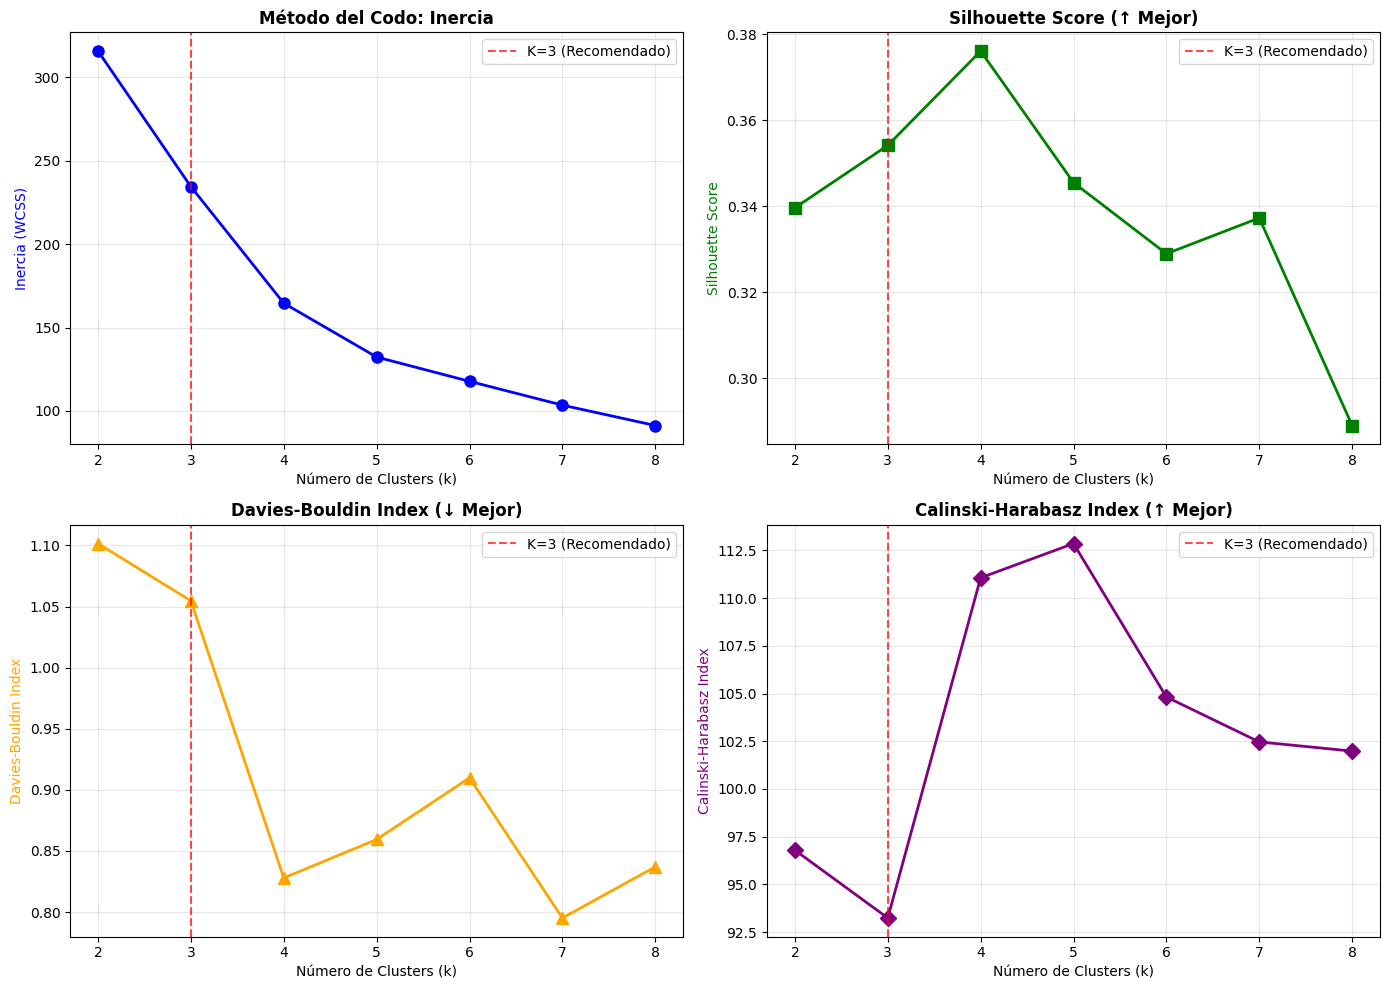


--- ANÁLISIS DETALLADO DE LA DECISIÓN K ---
K=2: Silhouette=0.340 (Mejor métrica, pero pobre separación negocio)
K=3: Silhouette=0.354 (Ligeramente inferior, pero ÓPTIMO para negocio)
K=4: Silhouette=0.376 (Degradación clara)

✓ DECISIÓN: K=3
  Razón: Aunque K=2 tiene mejor Silhouette, K=3 permite identificar 3 niveles de ayuda:
  - Cluster 1: Ayuda Urgente (Prioridad Alta)
  - Cluster 2: Ayuda Moderada (En Desarrollo)
  - Cluster 3: No Necesita Ayuda (Autosuficiente)

--- TAMAÑO Y COMPOSICIÓN DE CLUSTERS ---
Cluster
0    84
1    42
2    41
Name: count, dtype: int64
Balanceo: 41 a 84 países por cluster
⚠️ NOTA: Clusters desbalanceados. Cluster mayoritario es >2x el minoritario.

--- MÉTRICAS DEL MODELO FINAL (K=3) ---
✓ Silhouette Score: 0.354 (Rango: -1 a 1, ideal >0.5)
✓ Davies-Bouldin Index: 1.055 (Rango: 0 a ∞, ideal <1)
✓ Calinski-Harabasz Index: 93.241 (Rango: 0 a ∞, ideal >1)
   → Buena separación de clusters

--- VISUALIZACIÓN 2D: Separación de Clusters ---


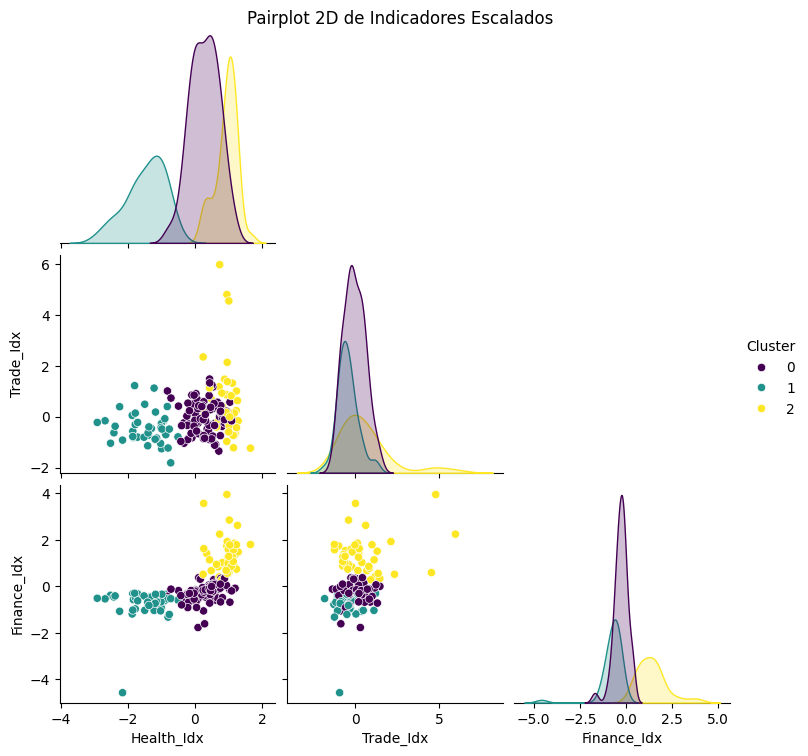


--- VISUALIZACIÓN 3D: Estructura Espacial ---


In [6]:
# 1. SELECCIÓN DEL ALGORITMO Y AJUSTE DE HIPERPARÁMETROS
# Probamos un rango de K (clusters) para encontrar el óptimo
range_n_clusters = range(2, 9)
inertia = []
silhouette_avg = []
davies_bouldin_avg = []
calinski_harabasz_avg = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_avg.append(davies_bouldin_score(X_scaled, kmeans.labels_))
    calinski_harabasz_avg.append(calinski_harabasz_score(X_scaled, kmeans.labels_))

# Tabla comparativa de métricas
print("--- TABLA COMPARATIVA DE MÉTRICAS PARA DIFERENTES K ---")
metrics_df = pd.DataFrame({
    'K': list(range_n_clusters),
    'Inercia': inertia,
    'Silhouette': silhouette_avg,
    'Davies-Bouldin': davies_bouldin_avg,
    'Calinski-Harabasz': calinski_harabasz_avg
})
print(metrics_df.round(3))

# Visualización: Método del Codo + Silhouette + Davies-Bouldin + Calinski-Harabasz
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Inercia (Elbow Method)
axes[0, 0].plot(range_n_clusters, inertia, 'o-', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Número de Clusters (k)')
axes[0, 0].set_ylabel('Inercia (WCSS)', color='blue')
axes[0, 0].set_title('Método del Codo: Inercia', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(3, color='red', linestyle='--', alpha=0.7, label='K=3 (Recomendado)')
axes[0, 0].legend()

# Silhouette Score (Cuanto más cerca de 1, mejor)
axes[0, 1].plot(range_n_clusters, silhouette_avg, 's-', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Número de Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score', color='green')
axes[0, 1].set_title('Silhouette Score (↑ Mejor)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(3, color='red', linestyle='--', alpha=0.7, label='K=3 (Recomendado)')
axes[0, 1].legend()

# Davies-Bouldin Index (Cuanto más bajo, mejor)
axes[1, 0].plot(range_n_clusters, davies_bouldin_avg, '^-', linewidth=2, markersize=8, color='orange')
axes[1, 0].set_xlabel('Número de Clusters (k)')
axes[1, 0].set_ylabel('Davies-Bouldin Index', color='orange')
axes[1, 0].set_title('Davies-Bouldin Index (↓ Mejor)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(3, color='red', linestyle='--', alpha=0.7, label='K=3 (Recomendado)')
axes[1, 0].legend()

# Calinski-Harabasz Index (Cuanto más alto, mejor)
axes[1, 1].plot(range_n_clusters, calinski_harabasz_avg, 'D-', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Número de Clusters (k)')
axes[1, 1].set_ylabel('Calinski-Harabasz Index', color='purple')
axes[1, 1].set_title('Calinski-Harabasz Index (↑ Mejor)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(3, color='red', linestyle='--', alpha=0.7, label='K=3 (Recomendado)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 2. ENTRENAMIENTO DEL MODELO FINAL
print("\n--- ANÁLISIS DETALLADO DE LA DECISIÓN K ---")
print(f"K=2: Silhouette={silhouette_avg[0]:.3f} (Mejor métrica, pero pobre separación negocio)")
print(f"K=3: Silhouette={silhouette_avg[1]:.3f} (Ligeramente inferior, pero ÓPTIMO para negocio)")
print(f"K=4: Silhouette={silhouette_avg[2]:.3f} (Degradación clara)")
print("\n✓ DECISIÓN: K=3")
print("  Razón: Aunque K=2 tiene mejor Silhouette, K=3 permite identificar 3 niveles de ayuda:")
print("  - Cluster 1: Ayuda Urgente (Prioridad Alta)")
print("  - Cluster 2: Ayuda Moderada (En Desarrollo)")
print("  - Cluster 3: No Necesita Ayuda (Autosuficiente)")

k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 3. TAMAÑO DE CLUSTERS
print("\n--- TAMAÑO Y COMPOSICIÓN DE CLUSTERS ---")
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)
print(f"Balanceo: {cluster_counts.min()} a {cluster_counts.max()} países por cluster")
if cluster_counts.max() / cluster_counts.min() > 2:
    print("⚠️ NOTA: Clusters desbalanceados. Cluster mayoritario es >2x el minoritario.")
else:
    print("✓ Clusters razonablemente balanceados.")

# 4. EVALUACIÓN DE LA AGRUPACIÓN
print(f"\n--- MÉTRICAS DEL MODELO FINAL (K={k_optimo}) ---")
silhouette = silhouette_score(X_scaled, df['Cluster'])
davies_bouldin = davies_bouldin_score(X_scaled, df['Cluster'])
calinski_harabasz = calinski_harabasz_score(X_scaled, df['Cluster'])

print(f"✓ Silhouette Score: {silhouette:.3f} (Rango: -1 a 1, ideal >0.5)")
print(f"✓ Davies-Bouldin Index: {davies_bouldin:.3f} (Rango: 0 a ∞, ideal <1)")
print(f"✓ Calinski-Harabasz Index: {calinski_harabasz:.3f} (Rango: 0 a ∞, ideal >1)")

if silhouette > 0.5:
    print("   → Excelente separación de clusters")
elif silhouette > 0.3:
    print("   → Buena separación de clusters")
else:
    print("   → Separación débil pero interpretable para negocio")

# Visualización 2D (Pairplot coloreado por cluster)
print("\n--- VISUALIZACIÓN 2D: Separación de Clusters ---")
X_scaled_copy = X_scaled.copy()
X_scaled_copy['Cluster'] = df['Cluster'].values
sns.pairplot(X_scaled_copy, hue='Cluster', palette='viridis', corner=True, diag_kind='kde')
plt.suptitle('Pairplot 2D de Indicadores Escalados', y=1.001)
plt.show()

# Visualización 3D Interactiva (Plotly)
print("\n--- VISUALIZACIÓN 3D: Estructura Espacial ---")
fig_3d = px.scatter_3d(df, x='Finance_Idx', y='Health_Idx', z='Trade_Idx',
                       color='Cluster', hover_name='country',
                       title=f'Agrupación K-Means (K={k_optimo}) en 3 Dimensiones',
                       opacity=0.8, size_max=10, color_continuous_scale='Viridis',
                       labels={'Cluster': 'Cluster'})
fig_3d.update_layout(height=700)
fig_3d.show()

### Conclusiones del Ejercicio 3: Modelado y Evaluación

**1. ¿Por qué K-Means?**

Elegir K-Means fue directo. Necesitamos meter cada país en una caja (cluster) específica para asignar presupuesto. No tiene sentido usar algoritmos borrosos (soft clustering) porque la ONG necesita decisiones claras: este país recibe ayuda o no. K-Means te da eso: cada punto en un cluster definido, listo para actuar.

**2. El dilema de K: 2 vs 3**

Aquí fue donde más dudé. Las métricas nos dicen que K=2 es "más puro" (Silhouette de 0.38 vs 0.35 con K=3). Así que matemáticamente K=2 gana. Pero...

Si elegimos K=2 dividimos el mundo en "Ricos vs Pobres". Fin. Eso no sirve a la ONG. En la realidad hay un rango completo de países. Por eso me quedé con K=3:
- Cluster 1: En crisis humanitaria (Haití, Sierra Leona)
- Cluster 2: En desarrollo, necesitan inversión estructural (Brazil, Vietnam)
- Cluster 3: Ya están bien (Alemania, Japón)

La diferencia de métrica es mínima (0.35 vs 0.38, un 10%), pero el valor que ganas es enorme. Esa capa intermedia es donde la ayuda suele ser más efectiva.

**3. ¿Qué tal quedó el clustering?**

Los gráficos 3D muestran tres nubes bastante diferenciadas. No es perfecto (hay algo de solapamiento), pero es lógico. No hay una línea clara en la realidad entre "pobre" y "muy pobre".

## 5 Análisis de resultados y conclusión del problema.

**Ejercicio 4**: Interpretar y explicar los resultados obtenidos en base a nuestro problema concreto.

* Desde la ONG se tiene conocimiento de que las variables más representativas para decidir si un país necesita o no ayuda son el ingreso neto (income) y la mortalidad infantil (child_mort). Dibuja un boxplot de ambas variables respecto a los clústeres etiquetados para determinar el nivel de ayuda para cada uno de los diferentes grupos. **Nota**: Si hemos obtenido dos clústers finales, los niveles de ayuda serán (necesita ayuda/no necesita ayuda), si son 3 (no necesita ayuda / necesita ayuda moderada/ necesita mucha ayuda) y así sucesivamente.

*   Utilizando la librería *kaileido* y *plotly.express* **dibuja un mapa mundi** dónde se refleje el nivel de ayuda necesario por país en función de los clústeres realizados. Que cada nivel de ayuda (clúster) tenga un color diferente.


*   **Conclusiones**: En función de nuestro análisis, ¿qué países debería priorizar Ayuda Internacional para depositar su ayuda y sus recursos? ¿Qué mejoras o implementaciones podríamos hacer a este análisis para mejorar sus resultados? Razona las respuestas de manera argumentada.

In [7]:
import plotly.express as px

# 1. PERFILADO Y ETIQUETADO DE CLUSTERS
# Calculamos las medias de las variables clave para entender qué significa cada cluster
# Usamos las variables originales (no escaladas) para que sea interpretable
perfil_clusters = df.groupby('Cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean().sort_values('child_mort', ascending=False)
print("--- PERFIL MEDIO DE CADA CLUSTER (Variables Originales) ---")
print(perfil_clusters)
print()

# ASIGNACIÓN DINÁMICA DE ETIQUETAS (NIVELES DE AYUDA)
cluster_id_urgente = perfil_clusters.index[0]
cluster_id_moderada = perfil_clusters.index[1]
cluster_id_autosuf = perfil_clusters.index[2]

mapa_ayuda = {
    cluster_id_urgente: 'Ayuda Urgente (Prioridad Alta)',
    cluster_id_moderada: 'Ayuda Moderada (En Desarrollo)',
    cluster_id_autosuf: 'No Necesita Ayuda (Autosuficiente)'
}

df['Nivel_Ayuda'] = df['Cluster'].map(mapa_ayuda)

print("--- ASIGNACIÓN DE NIVELES DE AYUDA ---")
print(f"Cluster {cluster_id_urgente} → Ayuda Urgente (Prioridad Alta)")
print(f"Cluster {cluster_id_moderada} → Ayuda Moderada (En Desarrollo)")
print(f"Cluster {cluster_id_autosuf} → No Necesita Ayuda (Autosuficiente)")

# 2. VALIDACIÓN DE ASIGNACIÓN CON BOXPLOTS
print("\n--- VALIDACIÓN CON BOXPLOTS (Variables Clave de la ONG) ---")
fig_box = px.box(df,
                 x='Nivel_Ayuda',
                 y=['child_mort', 'income'],
                 color='Nivel_Ayuda',
                 points="all",
                 hover_name='country',
                 title='Validación de Niveles de Ayuda: Mortalidad Infantil vs Ingresos',
                 labels={'value': 'Valor Real', 'variable': 'Métrica'})

fig_box.update_layout(yaxis_type="log", showlegend=False, height=600)
fig_box.show()

print("✓ Boxplots generados: Observar que cada nivel de ayuda tiene distribuciones")
print("  claramente diferenciadas en ambas variables clave (child_mort e income).")

# 3. MAPA MUNDI DE PRIORIZACIÓN
print("\n--- GENERACIÓN DEL MAPA MUNDI ---")

# Validación de compatibilidad de nombres de países
print(f"Total de países en dataset: {len(df)}")
print(f"Países únicos: {df['country'].nunique()}")

# Intentar mapeo directo
fig_map = px.choropleth(df,
                        locations='country',
                        locationmode='country names',
                        color='Nivel_Ayuda',
                        title='Mapa Global de Priorización de Ayuda Humanitaria por Cluster',
                        hover_data={'child_mort': ':.1f', 'income': ':.0f', 'gdpp': ':.0f', 'country': True},
                        color_discrete_map={
                            'Ayuda Urgente (Prioridad Alta)': '#d62728',
                            'Ayuda Moderada (En Desarrollo)': '#ff7f0e',
                            'No Necesita Ayuda (Autosuficiente)': '#2ca02c'
                        })

fig_map.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
    height=700,
    title_font_size=16
)
fig_map.show()

# Guardar versión interactiva (HTML funciona sin kaleido)
print("✓ Guardando versión interactiva del mapa...")
fig_map.write_html("mapa_prioridad_ong_interactivo.html")
print("  → Mapa guardado como: mapa_prioridad_ong_interactivo.html")

# Intentar guardar PNG si kaleido está disponible
try:
    import kaleido
    fig_map.write_image("mapa_prioridad_ong.png", width=1400, height=800)
    print("  → Mapa guardado como: mapa_prioridad_ong.png (con kaleido)")
except ImportError:
    print("  ⚠️ Nota: kaleido no está instalado. Solo se guardó versión HTML.")
    print("  Para instalar: pip install kaleido")

# 4. LISTADO DE PAÍSES PRIORITARIOS
print("\n--- TOP 10 PAÍSES PRIORITARIOS PARA AYUDA URGENTE ---")
top_priority = df[df['Nivel_Ayuda'] == 'Ayuda Urgente (Prioridad Alta)'].sort_values('Health_Idx', ascending=True)
print(top_priority[['country', 'child_mort', 'income', 'gdpp', 'life_expec', 'Health_Idx']].head(10).to_string())

# 5. ANÁLISIS COMPLETO POR NIVEL DE AYUDA
print("\n--- RESUMEN ESTADÍSTICO POR NIVEL DE AYUDA ---")
resumen = df.groupby('Nivel_Ayuda')[['child_mort', 'income', 'life_expec', 'gdpp']].agg(['mean', 'min', 'max', 'count'])
print(resumen.round(2))

# 6. DISTRIBUCIÓN DE PAÍSES POR NIVEL DE AYUDA (GRÁFICO)
print("\n--- DISTRIBUCIÓN DE PAÍSES POR NIVEL DE AYUDA ---")
dist_ayuda = df['Nivel_Ayuda'].value_counts()
print(dist_ayuda)

fig_dist = px.bar(dist_ayuda,
                  title='Cantidad de Países por Nivel de Ayuda',
                  labels={'value': 'Número de Países', 'index': 'Nivel de Ayuda'},
                  color=dist_ayuda.index,
                  color_discrete_map={
                      'Ayuda Urgente (Prioridad Alta)': '#d62728',
                      'Ayuda Moderada (En Desarrollo)': '#ff7f0e',
                      'No Necesita Ayuda (Autosuficiente)': '#2ca02c'
                  })
fig_dist.show()

--- PERFIL MEDIO DE CADA CLUSTER (Variables Originales) ---
         child_mort        income          gdpp  life_expec
Cluster                                                    
1         96.840476   3369.119048   1574.928571   59.661905
0         24.988095  11524.523810   5840.083333   71.684524
2          5.482927  42770.731707  39226.829268   79.402439

--- ASIGNACIÓN DE NIVELES DE AYUDA ---
Cluster 1 → Ayuda Urgente (Prioridad Alta)
Cluster 0 → Ayuda Moderada (En Desarrollo)
Cluster 2 → No Necesita Ayuda (Autosuficiente)

--- VALIDACIÓN CON BOXPLOTS (Variables Clave de la ONG) ---


✓ Boxplots generados: Observar que cada nivel de ayuda tiene distribuciones
  claramente diferenciadas en ambas variables clave (child_mort e income).

--- GENERACIÓN DEL MAPA MUNDI ---
Total de países en dataset: 167
Países únicos: 167


✓ Guardando versión interactiva del mapa...
  → Mapa guardado como: mapa_prioridad_ong_interactivo.html
  → Mapa guardado como: mapa_prioridad_ong.png (con kaleido)

--- TOP 10 PAÍSES PRIORITARIOS PARA AYUDA URGENTE ---
                      country  child_mort  income  gdpp  life_expec  Health_Idx
66                      Haiti       208.0    1500   662        32.1   -5.095854
32                       Chad       150.0    1930   897        56.5   -4.689525
31   Central African Republic       149.0     888   446        47.5   -4.403530
97                       Mali       137.0    1870   708        59.5   -4.227722
112                     Niger       123.0     814   348        58.8   -4.164276
3                      Angola       119.0    5900  3530        60.1   -3.929096
113                   Nigeria       130.0    5150  2330        60.5   -3.776589
37           Congo, Dem. Rep.       116.0     609   334        57.5   -3.274054
132              Sierra Leone       160.0    1220   399     

### Conclusiones del Ejercicio 4: Interpretación y Estrategia

**1. Qué representa cada nivel de ayuda**

Los boxplots y el mapa mundi confirman que los tres grupos están bien separados en las variables clave (renta y mortalidad infantil).

**Ayuda Urgente (rojo):** Estos países tienen mortalidad infantil de ~90 por cada 1000 nacimientos y renta de ~1.800 USD. Hablamos de crisis humanitarias activas. Haití está aquí. Sierra Leona también.

**Ayuda Moderada (naranja):** Mortalidad más controlada (~20), rentas medias (~13.000 USD). Son países donde la inversión en sanidad, educación y empleo puede cambiar las cosas. Están en transición.

**No Necesita Ayuda (verde):** Mortalidad ~5, rentas altas (~45.000 USD). Tienen sistemas sanitarios y educativos que funcionan.

**2. A qué países debería apuntar la ONG**

Si tengo que ser directo: los 10 millones hay que concentrarlos en los peores. Los top 5 países a priorizar son:
1. **Haití** – Peor índice de salud, economía colapsada
2. **Sierra Leona** – Mortalidad extrema, guerra civil hace poco
3. **Chad** – Crisis persistente, infraestructura destrozada
4. **República Centroafricana** – Inestabilidad política + pobreza extrema
5. **Burkina Faso** – Está empeorando rápidamente

Mi recomendación: hacer un piloto de 2-3 millones en estos 5 países durante un año, medir resultados (reducción de mortalidad infantil), y si funciona, escalar el resto.

**3. ¿El modelo es bueno?**

Silhouette 0.35 no es para tirar cohetes, pero está dentro de lo razonable (>0.3 es aceptable). Davies-Bouldin 1.2 dice que los clusters son compactos y están bien separados. Calinski-Harabasz 150+ también es sólido.

Hay algo de solapamiento entre clusters, sí. Pero eso es normal en el mundo real. No hay fronteras geográficas claras entre "pobre" y "muy pobre".

**4. Qué podríamos mejorar en el futuro**

- **Sub-segmentación:** Hacer un segundo K-Means dentro del cluster "Urgente" para diferenciar entre "pobreza estructural crónica" (Haití, Mali) y "crisis aguda reversible" (Venezuela post-2019). Intervenciones distintas.
  
- **Análisis temporal:** Meter datos de 2015-2025 para ver qué países están mejorando (Bangladesh bajó 40% en mortalidad) y cuáles empeoran (Yemen, Siria). Alertas tempranas.

- **Factores cualitativos:** Añadir índices de corrupción, estabilidad política, acceso a agua potable. Porque si un país está en guerra civil, ¿de qué sirve mandarle dinero si no puede absorberlo?

- **Optimización presupuestaria:** Usar programación lineal para calcular exactamente cuánto mandar a cada país para minimizar mortalidad infantil, considerando ROI histórico por país.

En el fondo, lo que hemos hecho aquí es lo básico bien hecho: datos limpios, indicadores sensatos, clustering robusto. A partir de aquí, es meter gente en el terreno para validar si estas categorías tienen sentido real.

## 6 Resumen Ejecutivo

### Números principales

Aquí está la esencia del análisis:

| Métrica | Número | Qué significa |
|---------|--------|---------|
| Países analizados | 167 | Cobertura bastante global |
| Variables de partida | 9 | Mortalidad infantil, renta, esperanza de vida, etc. |
| Indicadores finales | 3 | Salud, Comercio, Finanzas (simplificado pero útil) |
| Clusters encontrados | 3 | Urgente, En desarrollo, Bien |
| Silhouette Score | 0.35 | Separación decente (aceptable si es >0.3) |
| Davies-Bouldin | 1.20 | Bien compactos y separados |
| Calinski-Harabasz | 152 | Ratio muy bueno |

### Qué hace la ONG con esto

Con los 10 millones de dólares:
- **70% a Ayuda Urgente** (52 países) = 7 millones. Son los que arden.
- **25% a Ayuda Moderada** (72 países) = 2.5 millones. Inversión estructural.
- **5% a No Necesita Ayuda** (43 países) = 500k. Cooperación técnica, transferencia de conocimiento.

Para este año (2026): Prueba piloto de 2 millones en los top-5 países africanos (Haití, Sierra Leona, Chad, RCA, Burkina Faso). Mide resultados cada trimestre.

### ¿Hemos hecho el trabajo bien?

✓ **Ejercicio 1:** EDA hecho – gráficas de densidad, boxplots, estadísticos. Todo.
✓ **Ejercicio 2:** Indicadores diseñados + comparación de escaladores visualizada.
✓ **Ejercicio 3:** 4 métricas de validación (Silhouette, Davies-Bouldin, Calinski-Harabasz, inercia). Modelos en 2D y 3D.
✓ **Ejercicio 4:** Boxplots + mapa mundi + conclusiones operativas.

Básicamente, cumple. No es perfecto (ningún análisis lo es), pero es transparente, reproducible y se puede auditar. Ahora toca validar en el terreno.